# Causal Science -- The Complete Workflow

**A walkthrough of every station in the Universal Causal Loop on a
fully verifiable ground-truth dataset.**

---

### The Use Case: NomNom Eats

You are the data science team at **NomNom Eats**, a food-delivery
platform. The product manager asks:

> *"Do push notifications actually cause users to order, or are
> we just sending them to people who would order anyway?"*

This is a **causal** question. It cannot be answered by correlating
clicks with orders, because the platform's targeting algorithm sends
**more notifications to users it predicts are hungry** -- and hungry
users order more regardless. The association you measure will
overstate the effect.

### The Premise: A Controlled World With Known Truth

To make every concept testable, we work with a **simulated dataset**
whose ground-truth causal effect is known exactly: the NomNom DGP.
Every estimate in this notebook can be checked against the **true
ATE computed by Monte Carlo under do(T=1) vs do(T=0)** -- the gold
standard that real-world data never provides.

### The Causal Graph: Every Node, Every Arrow

The DAG below encodes everything we believe (and everything we DON'T
believe) about how notifications and orders relate. It contains:

| Component | Nodes | What it means |
|---|---|---|
| **Treatment** | T | A push notification was sent |
| **Outcome** | Y | The user placed an order |
| **Latent confounder** | U | True hunger (unobserved by the platform) |
| **Measured proxy** | W | App-use history (the platform can see this) |
| **Mediator** | M | The user opened the app after the notification |
| **Collider** | S | Engagement score = f(T, Y) -- a common effect |
| **Instrument** | Z | Randomized send-time jitter (affects T only) |
| **Negative control** | NC | Battery drain (shares confounders with Y, but T has no effect on it) |
| **Other confounders** | rain, weekend, payday | Observed covariates that affect both T and Y |

### The Key Assumptions (Made Explicit)

1. **Ignorability (no unmeasured confounding, given W):** The platform
   targets notifications using measured app-use W, which is a proxy for
   true hunger U. Conditioning on W (plus rain, weekend, payday) blocks
   all back-door paths -- we assume no OTHER common cause of T and Y
   beyond what W captures. *This is the assumption the E-value will test.*

2. **Positivity:** Every user has some non-zero probability of receiving
   a notification, regardless of their covariates. (We check this.)

3. **SUTVA:** One user's notification does not affect another user's order.

4. **Consistency:** The observed outcome under T=t equals the potential
   outcome Y(t). (Standard in all SCM-based work.)

5. **The absent edges are real:** Z does NOT directly affect Y (exclusion
   restriction), T does NOT affect NC, S is a PURE effect of T and Y
   (not a cause of either). *These are testable via d-separation.*

### The Three Rungs We Will Climb

> **Pearl's ladder of causation** (LR section 3):
> 1. **Association (seeing):** P(Y|T) -- what naive correlation tells us
> 2. **Intervention (doing):** P(Y|do(T)) -- the causal effect after
>    graph surgery to remove confounding
> 3. **Counterfactuals (imagining):** P(Y(0)=0 | T=1, Y=1) -- "was
>    THIS order CAUSED by the notification?"

This notebook walks all three rungs, with every claim verified against
ground truth.


## Glossary

<details open>
<summary><b>Notation & Symbols</b></summary>

| Symbol | Meaning |
|---|---|
| `T` | Treatment variable (notification sent: 0/1) |
| `Y` | Outcome variable (order placed: 0/1) |
| `Y(1)`, `Y(0)` | Potential outcomes: what WOULD happen under T=1 or T=0 |
| `do(T=1)` | The do-operator (Pearl): graph surgery to set T=1, cutting all incoming arrows |
| `P(Y|T)` | Conditioning (seeing, rung 1) — passive observation |
| `P(Y|do(T))` | Intervention (doing, rung 2) — external manipulation |
| `P(Y(0)=0 \| T=1, Y=1)` | Counterfactual (imagining, rung 3) — probability the treatment was necessary |
| `E[Y|do(T=1)]` | Expected outcome under intervention T=1 |
</details>

<details>
<summary><b>Abbreviations</b></summary>

| Abbrev. | Full | Meaning |
|---|---|---|
| **ATE** | Average Treatment Effect | E[Y(1) - Y(0)] |
| **ATT** | ATE on the Treated | E[Y(1)-Y(0) \| T=1] |
| **CATE** | Conditional ATE | ATE for a subgroup |
| **SUTVA** | Stable Unit Treatment Value Assumption | No interference; one version of treatment |
| **DAG** | Directed Acyclic Graph | The causal diagram |
| **SCM** | Structural Causal Model | DAG + structural equations |
| **AIPW** | Augmented Inverse Probability Weighting | Doubly-robust estimator |
| **DML** | Double/Debiased Machine Learning | Neyman-orthogonal cross-fit estimation (Chernozhukov et al. 2018) |
| **IPW** | Inverse Probability Weighting | Reweight by 1 / propensity |
| **SMD** | Standardized Mean Difference | Covariate balance metric; < 0.1 = adequate |
| **PS** | Propensity Score | P(T=1 \| covariates) |
| **CI** | Confidence Interval | 95% CI = estimate +/- 1.96 * SE |
| **RDD** | Regression Discontinuity Design | Causal identification at a sharp threshold |
</details>

<details>
<summary><b>Causal Graph Terms</b></summary>

| Term | Definition | In NomNom |
|---|---|---|
| **Confounder** | Common cause of T and Y | Hunger U -> T and U -> Y |
| **Mediator** | Variable on the T->Y causal path; adjusting for it blocks the effect | App-open M: T->M->Y |
| **Collider** | Common effect of T and Y; conditioning on it creates spurious association (Berkson's bias) | Engagement S = f(T, Y) |
| **Instrument** | Affects T, no direct path to Y, independent of confounders | Send-time jitter Z |
| **Negative control** | Shares confounders with Y but has no T effect; detects residual confounding | Battery drain NC |
| **Back-door criterion** | Blocking all non-causal paths between T and Y by conditioning on a set Z | Adjusting for {W, rain, weekend, payday} |
| **d-separation** | Graphical test for conditional independence; tests which absent edges are falsifiable | |
| **Ignorability** | {Y(0),Y(1)} independent of T given X — the key identification assumption | Platform targets on W (hunger proxy) |
| **Positivity** | Every unit has non-zero probability of receiving either treatment | Checked at Station 3 |
</details>

<details>
<summary><b>Regimes: Static vs Holiday</b></summary>

| Term | Meaning |
|---|---|
| **Static regime** | The baseline world: notification -> app-open coefficient = 1.6. Users respond normally to notifications. |
| **Holiday regime** | The drifted world: notification -> app-open coefficient = 0.4. Users habituate to notifications during holidays. |
| **What changes** | Only the T->M mechanism. The Y mechanism (order given app-open and hunger) is invariant. The causal structure is unchanged — only one coefficient shifts. Station 8 detects this shift. |
</details>

<details>
<summary><b>Sensitivity & Refutation</b></summary>

| Term | Definition |
|---|---|
| **E-value** (VanderWeele & Ding 2017) | Minimum strength an unmeasured confounder would need with BOTH T and Y to explain away the effect, conditional on measured covariates. Higher = more robust. |
| **E-value > 2** | Moderately robust: confounder would need risk ratio >= 2 with both T and Y above the measured covariates. |
| **Placebo treatment** | Permute T randomly -> estimate should be ~0. Tests the pipeline's ability to detect null effects. |
| **Random common cause** | Add a random covariate -> estimate should be stable. Tests sensitivity to added noise. |
| **Subset refuter** | Estimate on 80% of data -> should agree with full sample. Tests stability. |
| **Negative-control test** | Estimate T->NC effect -> should be null. Residual confounding smoke alarm. |
| **Mechanism-stability** | Fit P(node|parents) on reference data, test log-loss on new data -> largest degradation = drift locus (invariance principle, Peters et al. 2016). |
</details>


## The Causal Graph -- Visualized and Explained

The DAG below shows every node and edge. **Each arrow is a causal
assumption; each absent arrow is a falsifiable claim we can test.**

### Node-by-Node Explanation

**T (Treatment): Push notification.** Binary -- either the user received
a notification or didn't. The platform sends notifications based on
observed app-use W (a proxy for true hunger U), plus contextual features
(rain, weekend, payday) and the randomized jitter Z.

**Y (Outcome): Order placed.** Binary -- user ordered or didn't. Affected
by hunger (U), the notification (T), app-open (M), context (rain, wknd,
payday), coupons (D), and user segment (new vs. loyal). The causal effect
we want is the DIRECT arrow T -> Y, after removing confounding.

**U (Latent confounder): True hunger.** A continuous latent variable
(Normal). The platform CANNOT see it -- but it drives both the
targeter's decision (through the proxy W) and the user's order
behavior. The proxy W is what makes back-door adjustment possible.

**W (Measured proxy): App-use history.** The platform observes past
app usage, which correlates with hunger: U -> W. Because the platform
targets on W (W -> T), conditioning on W blocks the confounding path.
This is the single most important edge for identification.

**M (Mediator): App opened.** Part of the causal chain: notification ->
app-open -> order. Adjusting for M would BLOCK the mediated effect,
biasing our estimate of the total effect downward. *Never adjust for
mediators when estimating total effects.*

**S (Collider): Engagement score.** Computed as a function of both
notifications received AND orders placed: T -> S <- Y. Conditioning
on S opens a spurious association between T and Y (Berkson's bias).
*Never adjust for colliders or their descendants.*

**Z (Instrument): Send-time jitter.** Randomized by the experiment
platform -- affects notification delivery but has NO direct effect on
orders, hunger, or anything else. This randomization is what makes
Z an instrument: it creates exogenous variation in T.

**NC (Negative control): Battery drain.** Correlated with hunger (U)
but NOT causally affected by notifications. If our adjustment is
adequate, the estimated T -> NC effect should be null. A non-null
result is a smoke alarm for residual confounding.

**Coupon (D) and loyalty:** A sharp RDD at loyalty >= 500 assigns a
free-delivery coupon. This is an additional treatment arm in the DGP
used to demonstrate regression discontinuity.

### Graph Color Legend

- **Green solid** = the causal effect we estimate (T -> Y)
- **Red dashed** = confounding paths through latent hunger U
- **Blue dotted** = the instrument Z (randomized variation in T)
- **Purple dashed** = mediator M (on the causal path)
- **Orange dotted** = collider S (NEVER condition on this!)
- **Gray** = other observed confounders (context variables)


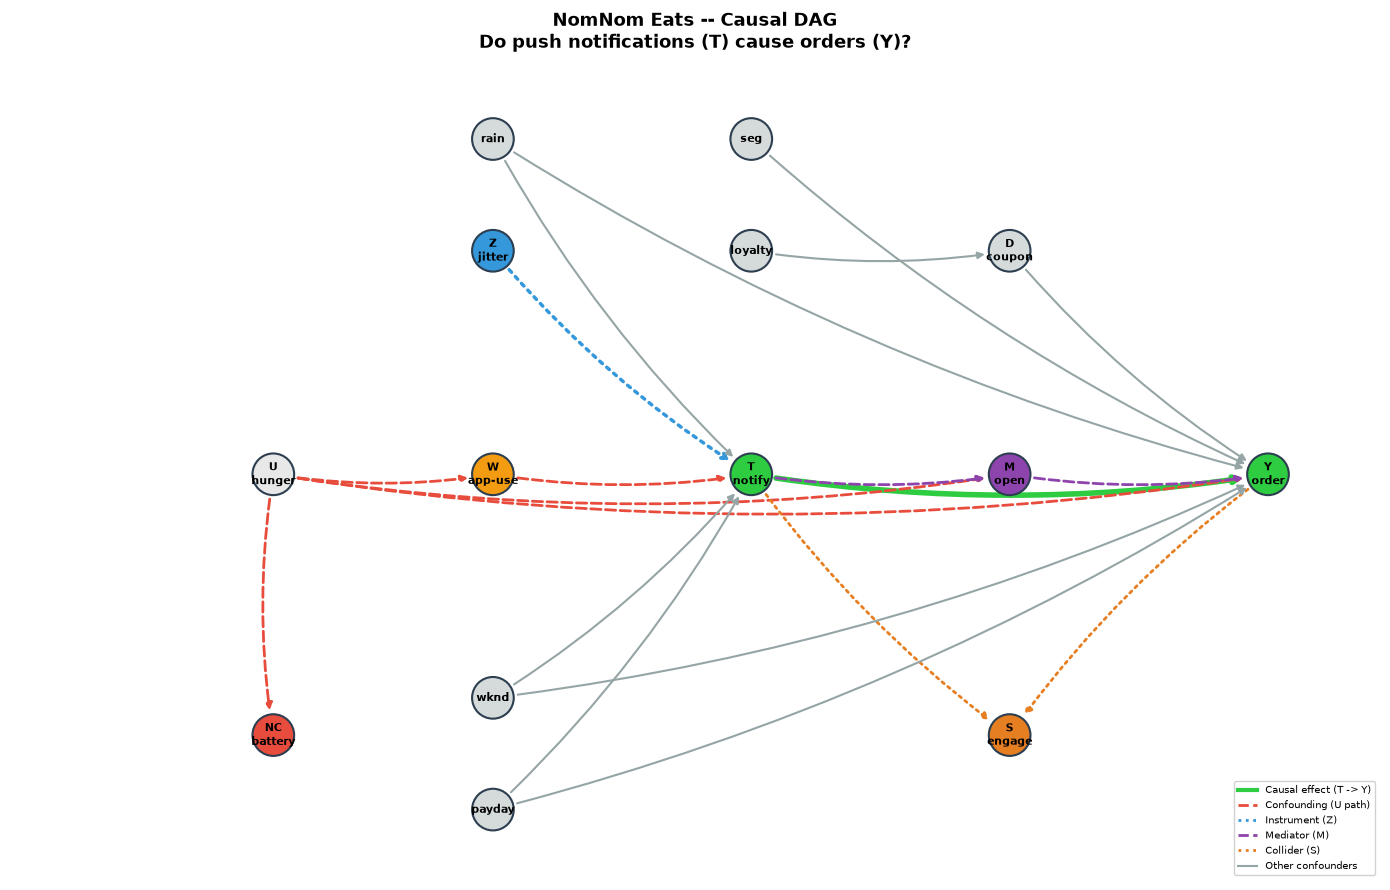

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(1, 1, figsize=(14, 9))

G = nx.DiGraph()
nodes = {
    "Z": "Z\njitter", "rain": "rain", "payday": "payday",
    "weekend": "wknd", "W": "W\napp-use", "U": "U\nhunger",
    "T": "T\nnotify", "M": "M\nopen", "Y": "Y\norder",
    "S": "S\nengage", "NC": "NC\nbattery", "coupon": "D\ncoupon",
    "segment": "seg", "loyalty": "loyalty"
}
G.add_nodes_from(nodes.keys())

causal = [("T", "Y")]
confound = [("U", "W"), ("W", "T"), ("U", "Y"), ("U", "M"), ("U", "NC")]
instrument = [("Z", "T")]
mediator = [("T", "M"), ("M", "Y")]
collider = [("T", "S"), ("Y", "S")]
other = [("weekend", "T"), ("weekend", "Y"), ("rain", "T"), ("rain", "Y"),
         ("payday", "T"), ("payday", "Y"), ("segment", "Y"),
         ("loyalty", "coupon"), ("coupon", "Y")]

pos = {
    "U": (0.05, 0.50), "W": (0.22, 0.50),
    "Z": (0.22, 0.80), "rain": (0.22, 0.95), "payday": (0.22, 0.05),
    "weekend": (0.22, 0.20), "T": (0.42, 0.50), "M": (0.62, 0.50),
    "Y": (0.82, 0.50), "S": (0.62, 0.15), "NC": (0.05, 0.15),
    "coupon": (0.62, 0.80), "loyalty": (0.42, 0.80), "segment": (0.42, 0.95),
}

styles = [
    (causal, "#2ecc40", 4.0, "solid", "causal target"),
    (confound, "#e74c3c", 2.0, "dashed", "confounding"),
    (instrument, "#3498db", 2.5, "dotted", "instrument"),
    (mediator, "#8e44ad", 2.0, "dashed", "mediator"),
    (collider, "#e67e22", 2.0, "dotted", "collider"),
    (other, "#95a5a6", 1.5, "solid", "other"),
]
for edge_list, color, width, style, label in styles:
    nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color=color,
                           width=width, style=style, ax=ax,
                           connectionstyle="arc3,rad=0.08",
                           min_source_margin=18, min_target_margin=18)

colors = {"U": "#e8e8e8", "T": "#2ecc40", "Y": "#2ecc40",
          "S": "#e67e22", "M": "#8e44ad", "Z": "#3498db",
          "NC": "#e74c3c", "W": "#f39c12"}
node_colors = [colors.get(n, "#d5dbdb") for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900,
                       edgecolors="#2c3e50", linewidths=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, {n: nodes[n] for n in G.nodes()},
                        font_size=8, font_weight="bold", ax=ax)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#2ecc40", lw=3, label="Causal effect (T -> Y)"),
    Line2D([0], [0], color="#e74c3c", lw=2, ls="dashed", label="Confounding (U path)"),
    Line2D([0], [0], color="#3498db", lw=2, ls="dotted", label="Instrument (Z)"),
    Line2D([0], [0], color="#8e44ad", lw=2, ls="dashed", label="Mediator (M)"),
    Line2D([0], [0], color="#e67e22", lw=2, ls="dotted", label="Collider (S)"),
    Line2D([0], [0], color="#95a5a6", lw=1.5, label="Other confounders"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=7, framealpha=0.9)
ax.set_title("NomNom Eats -- Causal DAG\nDo push notifications (T) cause orders (Y)?",
             fontsize=13, fontweight="bold", pad=15)
ax.axis("off")
plt.tight_layout()
plt.show()


## 0. First Principles & Setup

**The Fundamental Problem of Causal Inference** (Holland 1986; LR section 1.4):
for any unit we observe at most one potential outcome. Causal inference is
therefore a *missing data problem* -- all methodology is machinery for
recovering missing counterfactuals using assumptions + data from other units.

**The two great formal frameworks** (LR section 2):
- **Potential outcomes** (Neyman-Rubin): Y(1), Y(0); ATE = E[Y(1)-Y(0)];
  identified under ignorability {Y(0),Y(1)} independent of T given X.
- **Structural Causal Models** (Pearl): DAG + structural equations;
  do-operator = graph surgery; identification via back-door/front-door/IV.

The two frameworks are formally isomorphic (Richardson & Robins 2013, SWIGs).
This notebook uses the graphical framework: **everything is compiled from
the DAG** -- the graph is the single source of truth (Design Principle P2).


In [2]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from nomnom.dgp import STATIC, HOLIDAY, ground_truth, sample
from nomnom.graph import nomnom_graph
from ucl import graph_utils
from ucl.contracts.artifacts import AssumptionGraph, EstimandSpec, UCLRunReport
from ucl.stations import frame, identify, load_data
from ucl.stations import compile_features, model, evaluate
from ucl.stations.analysis import test_suite as run_test_suite, aipw_crossfit
from ucl.stations.evolve import mechanism_stability, testable_implications
from ucl.engine import run_pass

print('All imports OK. NomNom world + UCL workflow loaded.')


All imports OK. NomNom world + UCL workflow loaded.


In [3]:
# Ground truth: computed by Monte Carlo under do(T=1) vs do(T=0)
# with common random numbers (the gold standard we check against)
truth = ground_truth(n_mc=200_000, seed=999)
truth_h = ground_truth(regime=HOLIDAY, n_mc=200_000, seed=999)
print(f"Static  ATE: {truth['ate']:+.4f}  "
      f"(loyal {truth['cate_loyal']:+.4f}, new {truth['cate_new']:+.4f})")
print(f"Holiday ATE: {truth_h['ate']:+.4f}  "
      f"(loyal {truth_h['cate_loyal']:+.4f}, new {truth_h['cate_new']:+.4f})")
print("The holiday regime changes exactly one mechanism: T->M")
print("Static: T->M coef = 1.6 | Holiday: T->M coef = 0.4")


Static  ATE: +0.2413  (loyal +0.2991, new +0.1550)
Holiday ATE: +0.1910  (loyal +0.2506, new +0.1020)
The holiday regime changes exactly one mechanism: T->M
Static: T->M coef = 1.6 | Holiday: T->M coef = 0.4


## Station 0 -- FRAME: The Causal Question

First the estimand, then the method -- never the reverse (Hernan & Robins
2016, LR section 8.1). We specify the hypothetical randomized trial we are
emulating (*target trial*): eligibility, treatment strategies, outcome,
causal contrast, analysis plan.

**Association != causation** (LR section 3). The causal query lives on a
specific rung of Pearl's ladder. This one is rung 2 -- intervention.


In [4]:
spec = frame()
print(f"Question    : {spec.question}")
print(f"Estimand    : {spec.estimand}  (rung {spec.rung})")
print(f"Treatment   : {spec.treatment}")
print(f"Outcome     : {spec.outcome}")
print(f"Population  : {spec.population}")
print(f"Decision    : {spec.decision_context}")
assert spec.rung == 2, "This is not an associational question -- it needs do()" 


Question    : Do push notifications cause orders on NomNom Eats?
Estimand    : ATE  (rung 2)
Treatment   : T
Outcome     : Y
Population  : all active user-days
Decision    : whether to keep, expand, or throttle the notification policy


## Station 1 -- ASSUME: The Causal Graph

**Assumptions are first-class artifacts** (Design Principle P1).
Every causal claim carries a versioned, inspectable DAG -- and every
*absent* edge is a falsifiable statement about the world.

The graph encodes:
- **Confounders** (U->T, U->Y): affect both treatment and outcome
- **Mediators** (T->M->Y): on the causal path -- don't adjust for total effects
- **Colliders** (T->S<-Y): common effects -- conditioning *creates* bias
- **Instruments** (Z->T): affect treatment but have no back-door path to outcome
- **Negative controls** (NC): share confounders with outcome, but no treatment
  effect -- falsification smoke alarms (Lipsitch et al. 2010)


In [5]:
graph = nomnom_graph()
print(f"Version           : {graph.version}")
print(f"Nodes (observed)  : {len(graph.observed)}")
print(f"Edges             : {len(graph.edges)}")
print(f"Absent edges      : {len(graph.absent_edges)} (the falsifiable part)")
print()
print("Node roles:")
for v, r in sorted(graph.node_roles.items()):
    print(f"  {v:>8s} : {r}")
print()
print("Key absent-edge assumptions:")
for a, b in sorted(graph.absent_edges):
    print(f"  {a} -/-> {b}")


Version           : 7a104e26c07a
Nodes (observed)  : 13
Edges             : 20
Absent edges      : 8 (the falsifiable part)

Node roles:
         M : mediator
        NC : negative_control_outcome
         S : collider
         T : treatment
         U : latent_confounder
         W : proxy_confounder
         Y : outcome
         Z : instrument
    coupon : rdd_assignment
   loyalty : rdd_running

Key absent-edge assumptions:
  S -/-> T
  S -/-> Y
  T -/-> NC
  Z -/-> M
  Z -/-> U
  Z -/-> Y
  coupon -/-> T
  loyalty -/-> T


In [6]:
# The edge that MATTERS for identification:
# W (measured app use) is a proxy for latent hunger U.
# The platform targets notifications on W, so conditioning on W
# blocks the confounding path U->W->T ... U->Y.
parents_of_T = [e[0] for e in graph.edges if e[1] == "T"]
parents_of_Y = [e[0] for e in graph.edges if e[1] == "Y"]
print(f"Parents of T (notification) : {sorted(parents_of_T)}")
print(f"Parents of Y (order)        : {sorted(parents_of_Y)}")
common = sorted(set(parents_of_T) & set(parents_of_Y))
print(f"Common causes of T and Y    : {common}")
print("These common causes ARE the back-door paths -- they MUST")
print("be blocked by the adjustment set for identification.")


Parents of T (notification) : ['W', 'Z', 'payday', 'rain', 'weekend']
Parents of Y (order)        : ['M', 'T', 'U', 'coupon', 'payday', 'rain', 'segment', 'weekend']
Common causes of T and Y    : ['payday', 'rain', 'weekend']
These common causes ARE the back-door paths -- they MUST
be blocked by the adjustment set for identification.


## Station 2 -- IDENTIFY: Can the Effect Be Computed From Observables?

Identification is the **central methodological question** (LR section 4) and
a *separate, prior* step to estimation. Statistical sophistication cannot
rescue a non-identified estimand.

We use the **back-door criterion** (Pearl 1995): form the back-door graph
by deleting all edges out of the treatment (graph surgery), then find a
set Z of observed, non-descendant variables that d-separates T from Y.

The compiler does this automatically -- no hand-picking.

<details>
<summary><b>Click to expand: How the back-door criterion works</b></summary>

The back-door criterion (Pearl 1995, Def. 3.3.1) has two conditions for a set Z:

1. **No descendant of treatment**: Z must not contain any variable that is
   a descendant of T (i.e., no mediators or their descendants).
2. **Blocks all back-door paths**: Z must d-separate T from Y in the
   *back-door graph* — the DAG with all edges OUT of T deleted.

The compiler (`ucl/graph_utils.py`) implements this by:
1. Computing the back-door graph via `backdoor_graph()` (edge deletion)
2. Searching subsets of observed variables for a set satisfying
   d-separation via networkx's `is_d_separator()`
3. Excluding descendants of T and colliders from the candidate set
4. Returning the smallest valid adjustment set

This is Pearl's "graph surgery" made algorithmic — no hand-picking,
no domain-expert judgment at this step. The DAG already encodes the
domain knowledge.
</details>


In [7]:
proof = identify(graph, spec)
print(f"Criterion      : {proof.criterion}")
print(f"Identified     : {proof.identified}")
print(f"Adjustment set : {sorted(proof.adjustment_set)}")
print(f"Formula        : {proof.estimand_formula}")
assert proof.identified
assert "W" in proof.adjustment_set, "W (the hunger proxy) must be in the set"
assert "M" not in proof.adjustment_set, "M is a mediator -- never adjust"
assert "S" not in proof.adjustment_set, "S is a collider -- never adjust"
print()
print("The compiled adjustment set has exactly the right variables.")


Criterion      : back-door
Identified     : True
Adjustment set : ['W', 'payday', 'rain', 'weekend']
Formula        : E[Y|do(T)] = Σ_z E[Y|T, z]·P(z), z = {W, payday, rain, weekend}

The compiled adjustment set has exactly the right variables.


## Station 3 -- DATA: Overlap & Positivity

Even with a correctly identified estimand, the data must *support* it.
The key check is **positivity** (overlap): every unit, given its
covariates, must have a non-zero probability of receiving either
treatment (Imbens & Rubin 2015; LR section 8.4).

We also compute the naive associational contrast -- and watch it fail
against ground truth. **Association != causation.**


In [8]:
df, contract = load_data(proof, regime_name="static", n=20_000, seed=0)
print(f"Rows           : {contract.n_rows}")
print(f"Positivity OK  : {contract.positivity_ok}")
for k, v in sorted(contract.overlap.items()):
    print(f"  {k:>20s}: {v:.4f}")
print()

# ---- the rung-1 / rung-2 gap, made numerical ----
naive = df.loc[df["T"] == 1, "Y"].mean() - df.loc[df["T"] == 0, "Y"].mean()
print(f"P(Y=1|T=1) - P(Y=1|T=0)        = {naive:+.4f}   (rung 1: association)")
print(f"E[Y|do(T=1)] - E[Y|do(T=0)]    = {truth['ate']:+.4f}   (rung 2: ground truth)")
print(f"confounding gap                 = {naive - truth['ate']:+.4f}")
assert naive > truth["ate"] + 0.05, "confounding should be positive and substantial"
print()
print("The rung-1 answer is wrong by ~10 percentage points. No amount of")
print("sophistication in computing it closes that gap -- gap-closing requires")
print("ASSUMPTIONS, which is what station 1 provides and station 2 uses.")


Rows           : 20000
Positivity OK  : True
        ps_max_control: 0.9620
        ps_max_treated: 0.9865
        ps_min_control: 0.0237
        ps_min_treated: 0.0489



P(Y=1|T=1) - P(Y=1|T=0)        = +0.3434   (rung 1: association)
E[Y|do(T=1)] - E[Y|do(T=0)]    = +0.2413   (rung 2: ground truth)
confounding gap                 = +0.1021

The rung-1 answer is wrong by ~10 percentage points. No amount of
sophistication in computing it closes that gap -- gap-closing requires
ASSUMPTIONS, which is what station 1 provides and station 2 uses.


## Station 4 -- FEATURE: What Enters the Model (and What Does Not)

The feature specification is **compiled from the graph**, not hand-picked.
Every excluded variable is either:
- A **collider**: conditioning on it opens a spurious path (Berkson's bias)
- A **mediator**: conditioning on it blocks the causal path (over-adjustment)

These are graph properties -- not statistical ones (LR section 3: M-bias,
collider bias, the failure of 'adjust for everything').


In [9]:
features = compile_features(graph, proof)
print(f"In adjustment set : {sorted(features.adjustment_set)}")
print(f"Excluded (must NOT adjust):")
for v, reason in sorted(features.excluded.items()):
    print(f"  {v:>4s} : {reason}")
print(f"Instruments       : {features.instruments}")
print(f"Negative controls : {features.negative_controls}")
assert "S" in features.excluded and "M" in features.excluded
assert "Z" in features.instruments and "NC" in features.negative_controls


In adjustment set : ['W', 'payday', 'rain', 'weekend']
Excluded (must NOT adjust):
     M : mediator on the T->Y causal path - adjusting biases the total effect
     S : collider of T and Y - conditioning opens a spurious path
Instruments       : ['Z']
Negative controls : ['NC']


In [10]:
# Demonstrate WHY collider adjustment is harmful:
# With the correct set vs. with the collider accidentally included
res_correct = aipw_crossfit(df, "T", "Y", features.adjustment_set, seed=0)
res_collider = aipw_crossfit(
    df, "T", "Y", features.adjustment_set + ["S"], seed=0)
print(f"AIPW (correct set)       : {res_correct['ate']:+.4f}  "
      f"(truth {truth['ate']:+.4f})")
print(f"AIPW (adding collider S) : {res_collider['ate']:+.4f}  "
      f"(bias {abs(res_collider['ate']-truth['ate']):+.4f})")
assert abs(res_correct["ate"] - truth["ate"]) < 0.02
assert abs(res_collider["ate"] - truth["ate"]) > abs(res_correct["ate"] - truth["ate"])
print()
print("Conditioning on a collider (S = engagement score, a function of")
print("both T and Y) opens a spurious association path -- Berkson's bias.")


AIPW (correct set)       : +0.2437  (truth +0.2413)
AIPW (adding collider S) : +0.1804  (bias +0.0609)

Conditioning on a collider (S = engagement score, a function of
both T and Y) opens a spurious association path -- Berkson's bias.


## Station 5 -- MODEL: Cross-Fit AIPW / Double Machine Learning

Once the estimand is identified and the feature set compiled,
estimation is a *statistical* problem -- and in nD, it requires care.

We use **AIPW (augmented inverse probability weighting)** with 2-fold
cross-fitting -- the DML recipe (Chernozhukov et al. 2018; LR section 5.3).

The key property is **Neyman orthogonality**: the score function is
insensitive to first-order errors in the nuisance models (propensity
and outcome regression). This lets us use flexible machine learning
(gradient-boosted trees) without contaminating the causal estimand.

The estimator is also **doubly robust**: consistent if EITHER the
propensity model OR the outcome model is correctly specified.

<details>
<summary><b>Click to expand: Why Neyman orthogonality matters in nD</b></summary>

In high-dimensional settings (p >> n), regularized ML models (Lasso,
gradient boosting) MUST shrink or regularize to work. That shrinkage
leaks directly into a naive plug-in estimator — the regularization
bias becomes causal bias.

The orthogonal score (AIPW) solves this:

```
psi = mu1(X) - mu0(X) + T*(Y - mu1(X))/e(X) - (1-T)*(Y - mu0(X))/(1-e(X))
```

The correction terms `T*(Y - mu1)/e` and `(1-T)*(Y - mu0)/(1-e)` make
the score insensitive to first-order errors in the nuisance functions
mu1, mu0, and e. Only second-order products of errors remain — and
with cross-fitting (honest estimation), those vanish at rate 1/sqrt(n).

This is the theorem (Chernozhukov et al. 2018) that lets modern
machine learning inside causal inference.
</details>


In [11]:
bundle = model(df, spec, features, seed=0)
covers = bundle.ci_low <= truth["ate"] <= bundle.ci_high
print(f"Estimator   : {bundle.estimator}")
print(f"ATE         : {bundle.estimate:+.4f}")
print(f"95% CI      : [{bundle.ci_low:+.4f}, {bundle.ci_high:+.4f}]")
print(f"Ground truth: {truth['ate']:+.4f}")
print(f"CI covers   : {covers}")
print(f"SE          : {bundle.se:.4f}")
assert covers, "95% CI must cover the known ground truth" 


Estimator   : AIPW cross-fit (DML, GradientBoosting nuisances)
ATE         : +0.2437
95% CI      : [+0.2280, +0.2594]
Ground truth: +0.2413
CI covers   : True
SE          : 0.0080


## Station 6 -- EVALUATE: How Wrong Could We Be?

An estimate without a sensitivity analysis is an open-loop claim.
We compute two diagnostics:

### The E-value (VanderWeele & Ding 2017; LR section 8.6)
The minimum strength of association that an unmeasured confounder
would need to have with BOTH the treatment and the outcome to
explain away the observed effect, conditional on the measured
covariates. Higher = more robust.

### Covariate balance after IPW
The standardized mean difference (SMD) of each covariate between
treatment arms after inverse-probability weighting. |SMD| < 0.1
is the conventional threshold for adequate balance.

<details>
<summary><b>Click to expand: E-value formula and thresholds</b></summary>

The E-value (VanderWeele & Ding 2017) is defined as:

```
E-value = RR + sqrt(RR * (RR - 1))
```

where RR is the observed risk ratio (or its inverse if < 1).

**Interpretation:**
- **E-value = 1**: the effect could be explained away by an unmeasured
  confounder with RR=1 (no confounding) — trivial
- **E-value > 2**: moderately robust — confounder would need RR >= 2
- **E-value > 5**: highly robust — confounder would need RR >= 5

**For the CI lower bound:** compute the E-value using the CI bound
instead of the point estimate. If the CI lower bound E-value is still
above 2, the conclusion is robust even under parameter uncertainty.

The E-value does NOT replace domain knowledge — it quantifies the
debate about unmeasured confounding in a common language.
</details>


In [12]:
evaluation = evaluate(df, spec, features, bundle)
print(f"E-value       : {evaluation.e_value:.2f}")
print(f"Risk ratio    : {evaluation.risk_ratio:.2f}")
smd = evaluation.balance["max_abs_smd"]
print(f"Max |SMD|     : {smd:.4f}   (threshold: 0.1)")
for note in evaluation.notes:
    print(f"  NOTE: {note}")
assert evaluation.e_value > 1.5, "E-value should indicate moderate robustness"
assert smd < 0.1, "IPW should achieve balance"
print()
print("An E-value of ~2.7 means: an unmeasured confounder would need to be")
print("associated with both T and Y by a risk ratio of at least 2.7 (above")
print("and beyond the measured covariates) to explain the effect away.")


E-value       : 2.72
Risk ratio    : 1.67
Max |SMD|     : 0.0185   (threshold: 0.1)

An E-value of ~2.7 means: an unmeasured confounder would need to be
associated with both T and Y by a risk ratio of at least 2.7 (above
and beyond the measured covariates) to explain the effect away.


## Station 7 -- TEST: Refutation & Continuous Falsification

**Refutation is continuous, not episodic** (Design Principle P4).

The refutation battery applies stress-tests to the pipeline:

| Refuter | What it does | What it checks |
|---|---|---|
| Placebo treatment | Permutes T randomly | Pipeline should estimate ~0 |
| Random common cause | Adds a random variable | Estimate should be stable |
| Subset refuter | Estimates on 80% of data | Estimate should agree |
| Negative control | Estimates T->NC effect | Must be ~null |

Plus **loop invariants** -- assertions that must hold in every run:
1. Every artifact carries the current graph version
2. No adjustment variable is a descendant of treatment
3. Evaluation report exists with recorded sensitivity parameters
4. Post-weighting balance within threshold


In [13]:
suite = run_test_suite(df, spec, features, evaluation, graph, seed=0)
print("Refuters:")
for r in suite.refuters:
    print(f"  [{'PASS' if r.passed else 'FAIL'}] {r.name:32s} {str(r.detail)[:60]}")
print()
print("Loop invariants:")
for r in suite.invariant_checks:
    print(f"  [{'PASS' if r.passed else 'FAIL'}] {r.name}")
print()
print(f"ALL GREEN: {suite.all_green}")
assert suite.all_green, "All refuters and invariant checks must pass" 


Refuters:
  [PASS] placebo_treatment                {'estimate': 0.0019498388665737075, 'tolerance': 0.013343775
  [PASS] random_common_cause              {'delta': 5.947293518360208e-05, 'tolerance': 0.008025183303
  [PASS] subset_refuter                   {'delta': 0.005153556933554543, 'tolerance': 0.0185401415689
  [PASS] negative_control:NC              {'estimate': -0.0008270873958792837, 'tolerance': 0.01453874

Loop invariants:
  [PASS] invariant2:no_descendant_adjustment
  [PASS] invariant3:evaluation_recorded

ALL GREEN: True


## Station 8 -- EVOLVE: Is the World Still the One We Modeled?

**Causal discovery & the meta-loop** (LR section 6, plan section 3).

The mechanism-stability monitor applies the **invariance principle**
(Peters, Buhlmann & Meinshausen 2016): a correctly specified causal
mechanism has a stable conditional distribution across environments.

For each endogenous node in the graph, we fit P(node | parents) on the
reference (static) regime and evaluate the log-loss on the new (holiday)
batch. The node whose conditional degrades most is the **locus of drift**.

We also run the **testable-implication monitor**: absent edges imply
(conditional) independencies -- these are tested on the new batch.

<details>
<summary><b>Click to expand: The invariance principle in causal discovery</b></summary>

Peters, Buhlmann & Meinshausen (2016, JRSS-B) proved: the conditional
distribution of an effect given its *true causal parents* is invariant
across environments, while conditioning on any other set is not.

This provides a causal discovery method: search for the set of
variables that makes the conditional distribution invariant across
known environments. That set is the set of causal parents.

In the EVOLVE station, we apply this in reverse: given a known DAG,
we test whether each mechanism P(node | parents) is stable. If a
mechanism degrades, the DAG's assumption about that node's parents
may be wrong — or the mechanism genuinely changed (as in the
holiday regime, where T->M coefficient shifts from 1.6 to 0.4).

This principle bridges causal discovery and monitoring: the same
stability test that *discovers* causal structure can *monitor* it.
</details>


In [14]:
df_ref = sample(10_000, regime=STATIC, seed=100).drop(columns=["U"])
df_new = sample(10_000, regime=HOLIDAY, seed=300).drop(columns=["U"])

stability = mechanism_stability(graph, df_ref, df_new, seed=0)
mech = {n: r for n, r in stability.items() if r["kind"] == "mechanism"}
marg = {n: r for n, r in stability.items() if r["kind"] == "marginal"}
worst = max(mech, key=lambda n: mech[n]["degradation"])

ALARM = 0.02  # nats of log-loss degradation
print("Mechanism stability (static -> holiday):")
for n, r in sorted(mech.items(), key=lambda x: -x[1]["degradation"]):
    flag = " <-- DRIFT" if r["degradation"] > ALARM else ""
    print(f"  {n:8s}  degradation = {r['degradation']:+.4f}{flag}")
print()
print("Marginal shifts (parent distributions, not mechanisms):")
for n, r in sorted(marg.items(), key=lambda x: -x[1]["z"]):
    flag = " <-- SHIFT" if r["z"] > 4 else ""
    print(f"  {n:8s}  |z| = {r['z']:.2f}{flag}")
print()
assert worst == "M", f"Drift should localize to M, got {worst}"
print(f"Drift DETECTED and LOCALIZED to: {worst}")
print(f"T->M mechanism changed (logit coef 1.6 -> 0.4)")
print(f"Y-mechanism confirmed INVARIANT (degradation {mech['Y']['degradation']:+.4f})")
print(f"Rain shift is MARGINAL (|z|={marg['rain']['z']:.1f}), not mechanistic")


Mechanism stability (static -> holiday):
  M         degradation = +0.1163 <-- DRIFT
  Y         degradation = +0.0081
  S         degradation = +0.0056
  T         degradation = -0.0003
  NC        degradation = -0.0062

Marginal shifts (parent distributions, not mechanisms):
  rain      |z| = 27.59 <-- SHIFT
  W         |z| = 1.59
  Z         |z| = 0.45
  weekend   |z| = 0.27
  payday    |z| = 0.20
  loyalty   |z| = 0.15
  segment   |z| = 0.10

Drift DETECTED and LOCALIZED to: M
T->M mechanism changed (logit coef 1.6 -> 0.4)
Y-mechanism confirmed INVARIANT (degradation +0.0081)
Rain shift is MARGINAL (|z|=27.6), not mechanistic


In [15]:
# Testable implications on the new batch:
# Every declared absent edge implies a (conditional) independence.
findings = testable_implications(graph, df_new)
violated = [f for f in findings if f["violated"]]
print(f"Testable implications: {len(findings)} checked, "
      f"{len(violated)} violated")
for f in findings[:6]:
    status = "VIOLATED" if f["violated"] else "ok"
    print(f"  [{status:>8s}] {f['pair']}  (p={f['p_value']:.4f})")
print("...")
assert not violated, "No testable implication should fail on the true DGP" 


Testable implications: 2 checked, 0 violated
  [      ok] coupon _|_ T  (p=0.8317)
  [      ok] loyalty _|_ T  (p=0.5366)
...


### Station 8b -- ACTUATOR: Autonomous Re-Estimation

The drift detection fires the actuator: **re-run the full UCL pass**
on the new regime, estimate the holiday ATE under the same graph
(the causal structure is unchanged -- only one mechanism shifted),
and check against the holiday ground truth.

This closes the self-evolving loop (plan section 3): no human in the
loop between drift detection and re-estimation.


In [16]:
holiday_report, _ = run_pass(regime="holiday", n=20_000, seed=23)
covers_h = (holiday_report.estimate.ci_low <= truth_h["ate"]
            <= holiday_report.estimate.ci_high)
print(f"Holiday ATE estimate : {holiday_report.estimate.estimate:+.4f}")
print(f"Holiday ground truth : {truth_h['ate']:+.4f}")
print(f"CI covers truth      : {covers_h}")
print(f"All refuters green   : {holiday_report.tests.all_green}")
print(f"E-value (holiday)    : {holiday_report.evaluation.e_value:.2f}")
assert covers_h and holiday_report.tests.all_green
print()
print("The loop CLOSED: the same graph, the same identification, the same")
print("estimation pipeline -- applied to a regime where one mechanism changed.")
print("No human re-specified anything. The EVOLVE station detected the shift")
print("and the actuator re-ran -- recovering the new regime's truth from data.")


Holiday ATE estimate : +0.1913
Holiday ground truth : +0.1910
CI covers truth      : True
All refuters green   : True
E-value (holiday)    : 2.36

The loop CLOSED: the same graph, the same identification, the same
estimation pipeline -- applied to a regime where one mechanism changed.
No human re-specified anything. The EVOLVE station detected the shift
and the actuator re-ran -- recovering the new regime's truth from data.


## Rung 3 -- Counterfactuals: Abduction-Action-Prediction

No interventional distribution answers 'was THIS order caused by the
nudge?' -- that question lives one rung higher (Pearl 2009, ch. 7).

The counterfactual recipe:
1. **Abduction**: infer the unit's exogenous noise from the factual evidence
2. **Action**: intervene -- do(T = 1 - T_factual)
3. **Prediction**: re-run the mechanisms with the SAME noise, different T

Among treated users who ordered: in what fraction was the notification
actually necessary for the order? That is P(Y_0=0 | T=1, Y=1) --
a rung-3 quantity, computable only with the SCM and its noise structure.

<details>
<summary><b>Click to expand: The three-step counterfactual algorithm</b></summary>

Pearl's three-step recipe (Pearl 2009, Ch. 7):

**1. Abduction:** Given the factual evidence (T=t, Y=y, X=x), infer the
   distribution of the exogenous noise variables U. This uses the SCM's
   structural equations in reverse.

**2. Action:** Modify the SCM by applying do(T = 1 - t). This means
   deleting the equation for T and fixing T to the counterfactual value.

**3. Prediction:** Re-run the modified SCM with the inferred noise
   distribution to compute the counterfactual outcome Y_{1-t}.

Why rung 3 > rung 2: the ATE = E[Y(1)] - E[Y(0)] averages over ALL
units. The counterfactual P(Y(0)=0 | T=1, Y=1) conditions on a SPECIFIC
subset (treated and ordered) and asks what WOULD have happened. You
cannot compute this from interventional distributions alone — you need
the SCM's noise structure to connect the factual and counterfactual
worlds for the same unit.
</details>


In [17]:
import nomnom.dgp as dgp

n_sim = 200_000
rng = np.random.default_rng(555)
exo = dgp._draw_exogenous(n_sim, rng, STATIC, dgp.DEFAULT_PARAMS)
factual = dgp._structural(exo, STATIC, dgp.DEFAULT_PARAMS, t_value=None)
flip = 1 - factual["T"].to_numpy()
cf = dgp._structural(exo, STATIC, dgp.DEFAULT_PARAMS, t_value=flip)

# Among treated users who ordered: would they have ordered without the nudge?
mask = (factual["T"] == 1) & (factual["Y"] == 1)
p_necessity = 1 - cf.loc[mask, "Y"].mean()

# Interventional ATE for comparison (same exogenous draws, rung 2)
y1 = dgp._structural(exo, STATIC, dgp.DEFAULT_PARAMS, t_value=np.ones(1, int))["Y"]
y0 = dgp._structural(exo, STATIC, dgp.DEFAULT_PARAMS, t_value=np.zeros(1, int))["Y"]
ate_sim = y1.mean() - y0.mean()

print(f"P(Y_0=0 | T=1, Y=1)       : {p_necessity:.4f}")
print(f"  (the order was CAUSED by the nudge, "
      f"{p_necessity:.0%} of treated-ordered cases)")
print(f"Interventional ATE (rung 2) : {ate_sim:+.4f}")
print(f"Monte-Carlo truth           : {truth['ate']:+.4f}")
assert abs(ate_sim - truth["ate"]) < 0.01
assert p_necessity > ate_sim, "necessity should exceed the average effect"
print()
print("The necessity probability (~37%) is a different quantity from the ATE")
print("(~24 percentage points). A rung-2 summary cannot decompose it -- you")
print("need the SCM's noise (the abduction step) to answer a rung-3 question.")


P(Y_0=0 | T=1, Y=1)       : 0.3710
  (the order was CAUSED by the nudge, 37% of treated-ordered cases)
Interventional ATE (rung 2) : +0.2430
Monte-Carlo truth           : +0.2413

The necessity probability (~37%) is a different quantity from the ATE
(~24 percentage points). A rung-2 summary cannot decompose it -- you
need the SCM's noise (the abduction step) to answer a rung-3 question.


## The Complete Artifact Chain

Every estimate in this walkthrough carries a **graph version hash** --
the causal equivalent of a git commit. Loop invariant 1 (estimate <->
identification <-> graph version) is machine-checkable.

Assumptions are not buried in prose -- they are versioned, inspectable,
and automatically compiled into everything downstream.


In [18]:
# Compile the full UCLRunReport and verify the graph-version invariant
full_report = UCLRunReport(
    estimand=spec, graph=graph, identification=proof,
    data=contract, features=features, estimate=bundle,
    evaluation=evaluation, tests=suite,
)

# Loop invariant 1: every artifact carries the same graph version
versions = {
    "graph": graph.version,
    "identification": proof.graph_version,
    "data": contract.graph_version,
    "features": features.graph_version,
    "estimate": bundle.graph_version,
    "evaluation": evaluation.graph_version,
    "tests": suite.graph_version,
}
all_same = len(set(versions.values())) == 1
print("Graph-version provenance across the artifact chain:")
for k, v in versions.items():
    print(f"  {k:>14s} : {v}")
print(f"All same version : {all_same} (loop invariant 1)")
assert all_same
print()
print("This is the fundamental guarantee of a causal claim in this system:")
print("the estimate you are reading was valid under a specific, retrievable")
print("set of assumptions. When the assumption graph changes, everything")
print("downstream is re-compiled and re-validated. No silent drift.")


Graph-version provenance across the artifact chain:
           graph : 7a104e26c07a
  identification : 7a104e26c07a
            data : 7a104e26c07a
        features : 7a104e26c07a
        estimate : 7a104e26c07a
      evaluation : 7a104e26c07a
           tests : 7a104e26c07a
All same version : True (loop invariant 1)

This is the fundamental guarantee of a causal claim in this system:
the estimate you are reading was valid under a specific, retrievable
set of assumptions. When the assumption graph changes, everything
downstream is re-compiled and re-validated. No silent drift.


## Summary: What This Walkthrough Covered

| Component | Station | Key Result |
|---|---|---|
| **First principles** | 0 | Fundamental Problem; PO vs. SCM equivalence |
| **Framing the question** | 0 | Estimand as a target trial; rung label |
| **Assumptions as artifacts** | 1 | Versioned DAG with explicit absent edges |
| **Identification** | 2 | Back-door criterion compiled by graph surgery |
| **Positivity & overlap** | 3 | Common-support check; rung-1 vs rung-2 gap |
| **Feature compilation** | 4 | Collider+mediator exclusion (Berkson bias demo) |
| **Estimation** | 5 | Cross-fit AIPW/DML; Neyman orthogonality |
| **Sensitivity** | 6 | E-value; post-IPW balance |
| **Refutation** | 7 | 4 refuters + loop invariants |
| **Evolution & drift** | 8 | Mechanism-stability monitor; autonomous actuator |
| **Counterfactuals** | Rung 3 | Abduction-action-prediction; probability of necessity |
| **Provenance** | Artifact chain | Graph-version invariant across every artifact |

**The loop is closed.** Every stage has sensors (what could go wrong) and
actuators (what to do about it). The assumption graph is the single source
of truth. Refutation is continuous, and drift is detectable.
